# 5_visualizations

## Project: The "Broken Haven" Hypothesis

This notebook focuses on exploratory data analysis (EDA) and visualization for the Broken Haven project.

The main goal is to examine whether the relationship between gold returns and market stress changed after the COVID-19 period. In particular, this notebook provides descriptive evidence for a possible post-COVID structural shift and prepares charts for the final presentation.

## Section：1 Load and Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Check：
The cleaned dataset was loaded and sorted by date before visualization.

In [3]:
df = pd.read_csv("../data/final_model_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Number of observations:", len(df))

Date range: 2010-10-05 00:00:00 to 2025-09-09 00:00:00
Number of observations: 3894


In [4]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


## Section：2 Time-Series Visualizations

The modelling file defines the post-COVID period using the dummy variable `is_PostCovid`, which equals 1 from January 1, 2022 onward.

This section first creates readable period labels and then visualizes key variables over time.

In [5]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-05,0,Pre-2022
1,2010-10-06,0,Pre-2022
2,2010-10-07,0,Pre-2022
3,2010-10-08,0,Pre-2022
4,2010-10-11,0,Pre-2022


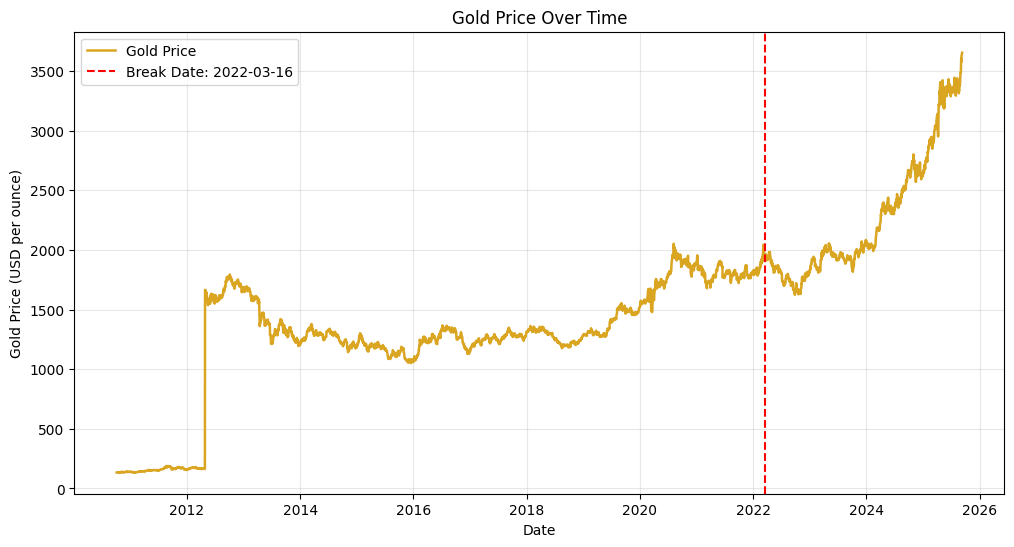

In [9]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_MGC_F"], color="goldenrod", linewidth=1.8, label="Gold Price")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

This figure shows how gold prices moved over time, with March 16, 2022 marked as the structural break date. Gold prices continue to fluctuate before and after the break, which suggests that market conditions may have changed across the two periods. This provides background for testing whether gold behaved differently after the break.

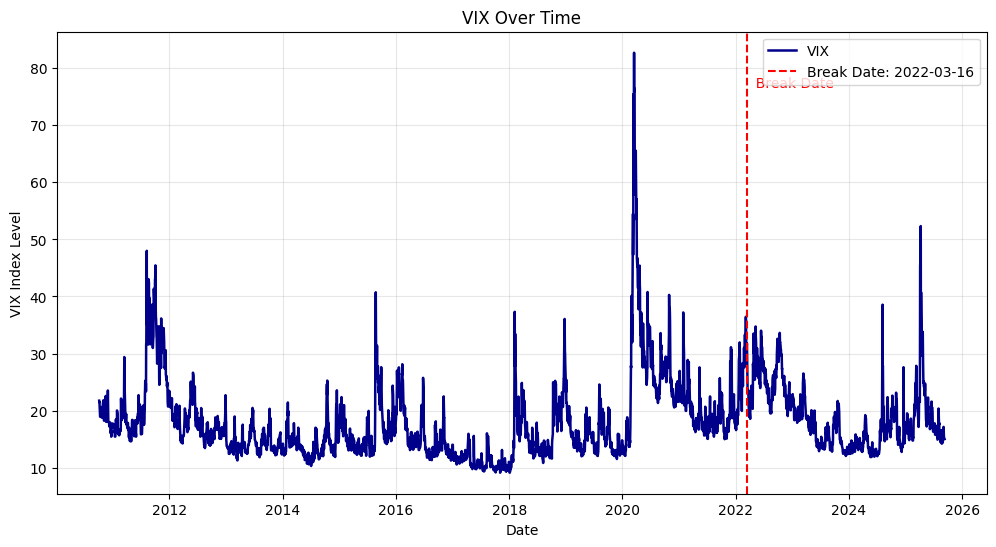

In [10]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_VIX"], color="darkblue", linewidth=1.8, label="VIX")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("VIX Over Time")
plt.xlabel("Date")
plt.ylabel("VIX Index Level")
plt.legend()
plt.grid(alpha=0.3)

y_max = df["Close_VIX"].max()
plt.text(split_date, y_max * 0.95, "  Break Date", color="red", va="top")

plt.show()

The VIX measures market stress and uncertainty. Since the project tests whether gold retained its safe-haven role, this is one of the most important explanatory variables.

## Section：3 Connecting Gold Prices and Market Stress

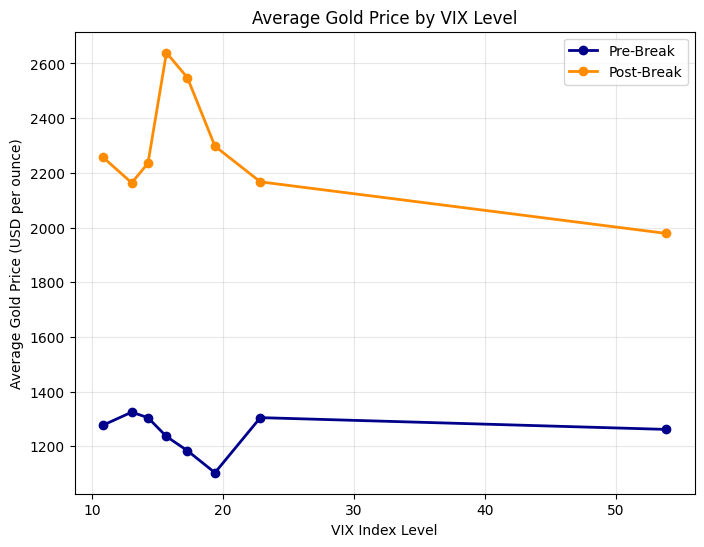

In [15]:
split_date = pd.Timestamp("2022-03-16")
df["Period"] = np.where(df["DATE"] >= split_date, "Post-Break", "Pre-Break")

plot_df = df[["Close_VIX", "Close_MGC_F", "Period"]].dropna().copy()
plot_df["VIX_bin"] = pd.qcut(plot_df["Close_VIX"], q=8, duplicates="drop")

grouped = plot_df.groupby(["Period", "VIX_bin"], observed=False)["Close_MGC_F"].mean().reset_index()
grouped["VIX_mid"] = grouped["VIX_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8,6))

for period, color in [("Pre-Break", "darkblue"), ("Post-Break", "darkorange")]:
    subset = grouped[grouped["Period"] == period]
    plt.plot(
        subset["VIX_mid"],
        subset["Close_MGC_F"],
        marker="o",
        linewidth=2,
        color=color,
        label=period
    )

plt.title("Average Gold Price by VIX Level")
plt.xlabel("VIX Index Level")
plt.ylabel("Average Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Interpretation

After examining gold prices and VIX separately over time, the next step is to look at how they are related. This figure compares average gold prices across different levels of market stress before and after the structural break on March 16, 2022.

If gold responded to market stress in the same way across both periods, the two lines would show a similar pattern. If the pattern differs after the break, this suggests that the relationship between gold and market stress may have become less stable.

This makes it reasonable to move from descriptive visual evidence to a formal test in the model. For that reason, the next figure introduces the interaction term `VIX × Post-Break`, which is designed to capture whether the effect of market stress changed after the break date.

## Section :4 Capturing the Post-Break Effect

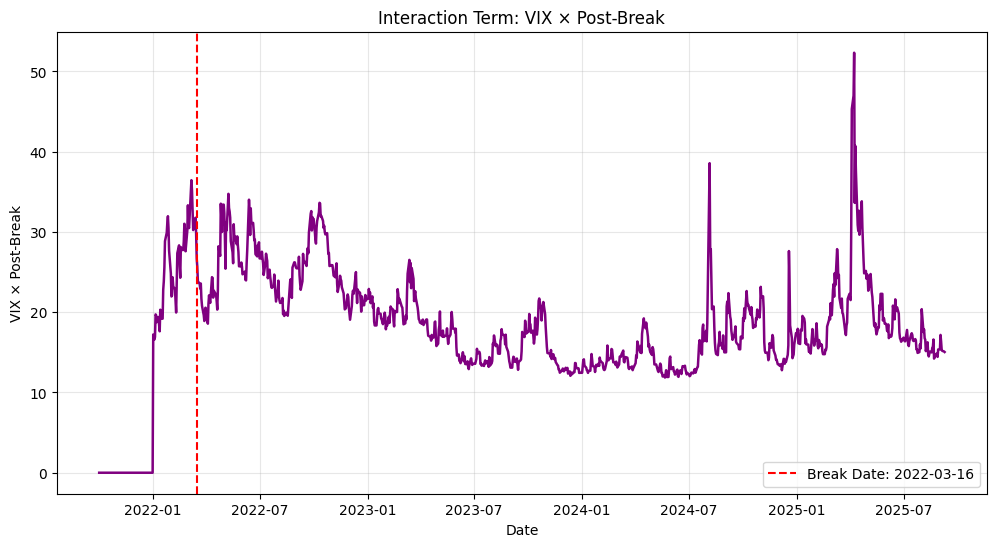

In [14]:
plot_df = df[df["DATE"] >= "2021-10-01"].copy()
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(plot_df["DATE"], plot_df["VIX_x_PostCovid"], color="purple", linewidth=1.8)
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("Interaction Term: VIX × Post-Break")
plt.xlabel("Date")
plt.ylabel("VIX × Post-Break")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

This figure shows the interaction term `VIX × Post-Break`, which is constructed to capture market stress only after the structural break date of March 16, 2022. Before the break, the variable is equal to zero. After the break, it moves together with VIX, reflecting the level of market stress in the post-break period only.

This is important because the project is not only asking whether market stress matters for gold, but whether its effect changed after the break. By isolating the post-break component of VIX, this variable allows the regression model to test whether the relationship between gold and market stress became different in the new market environment.

## Section：6 Model Results Summary

### 6.1 Lasso Feature Selection Summary

The modelling stage first applied Lasso regression to the candidate predictors in order to reduce multicollinearity and identify the most relevant variables for explaining daily gold returns.

However, under the current specification, the Lasso penalty shrank all coefficients to zero. This suggests that none of the candidate variables showed strong enough predictive power to remain in the model after regularization.

Because of this result, the analysis proceeded with a fallback variable set based on correlation patterns and modelling judgment. The variables passed to the OLS stage were:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `VIX_x_PostCovid`

This outcome suggests that daily gold returns may be difficult to predict using these macro-financial variables alone, possibly because gold returns are dominated by short-term noise.

### 6.2 OLS Regression Results

The final interaction model was estimated using OLS with HC3 robust standard errors. The model included the following predictors:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `Close_VIX`
- `is_PostCovid`
- `VIX_x_PostCovid`

The main purpose of this specification was to test whether the relationship between market stress and gold returns changed in the post-COVID period.

The regression results show that the interaction term `VIX_x_PostCovid` is not statistically significant. In addition, `Close_VIX` and `is_PostCovid` are also not statistically significant. This means that the model does not provide strong evidence that the effect of VIX on gold returns changed after the post-COVID break.

Among the included variables, `Close_DX_Y_NYB` is the closest to significance, but it still does not reach the 5% significance level. Overall, the model has very low explanatory power, which indicates that the selected predictors explain only a very small share of the variation in daily gold returns.

Therefore, while the descriptive plots may suggest some visual differences across periods, the formal OLS results do not strongly support the Broken Haven hypothesis.
| Variable | Coefficient | p-value | Interpretation |
|----------|-------------|---------|----------------|
| Close_DX_Y_NYB | -0.0001 | 0.063 | Negative but not significant at the 5% level |
| wti_crude_oil_price | -9.458e-07 | 0.979 | No significant relationship |
| sp500_ret_lag | 0.0528 | 0.196 | No significant relationship |
| Close_VIX | 6.826e-06 | 0.892 | No significant relationship |
| is_PostCovid | 0.0021 | 0.174 | No significant shift in average gold returns |
| VIX_x_PostCovid | -2.582e-05 | 0.795 | No significant post-COVID change in the VIX effect |

### 6.3 XGBoost Results

In addition to the OLS model, we applied XGBoost as a nonlinear machine learning benchmark to examine whether a more flexible specification could better capture the relationship between gold returns and macro-financial variables.

Using the same structural break date of March 16, 2022, the XGBoost model was trained on the pre-break sample and then evaluated on the post-break period. This approach allows us to test whether a model that performs well in the “old world” can still generalize after the suspected shift in market structure.

At the daily level, the XGBoost model does not perform well out of sample. The training RMSE is 4.761354%, while the testing RMSE increases to 2.153756%, compared with post-break market volatility of about 0.96%. In addition, the daily XGBoost model produces negative R-squared values in both the training and testing samples, which suggests that daily gold returns remain highly noisy and difficult to predict.

At the weekly level, however, the XGBoost model performs much better in-sample. It achieves a training RMSE of 1.985131% and a training R-squared of 0.9584, suggesting that nonlinear relationships may have been important in the pre-break period. The most important predictors in the weekly model are `wti_crude_oil_price` and `gold_vol_weekly`, which together account for most of the model’s predictive importance.

However, the weekly model also weakens noticeably in the post-break period. The testing RMSE rises to 2.089248%, and the testing R-squared falls to -0.0137. This suggests that even a stronger nonlinear model struggles to generalize after March 16, 2022.

Overall, the XGBoost results complement the OLS findings. They suggest that pre-break gold-return dynamics may contain nonlinear structure, but the predictive relationship becomes less stable in the post-break period. This provides additional support for the idea that the historical “safe-haven” relationship became harder to capture after the structural break.

| Model | Train RMSE | Test RMSE | Train R² | Test R² | Main Takeaway |
|------|------------|-----------|----------|---------|---------------|
| Daily XGBoost | 4.761354% | 2.153756% | -0.1903 | -4.0756 | Very weak predictive power; daily returns remain noisy |
| Weekly XGBoost | 1.985131% | 2.089248% | 0.9584 | -0.0137 | Strong in-sample fit, but weak post-break generalization |

## Section： 7 conclusion

This project examined whether the relationship between gold returns and market stress changed after the COVID period. The descriptive visualizations suggest that the post-COVID sample differs from the earlier period in several ways, especially in terms of market conditions and the behavior of gold returns.

The modelling results indicate that the relationship is more complex than a simple structural break story. While the visual patterns suggest that gold may not behave in exactly the same way as before, the regression results show that this change is not captured strongly under the current specification. In particular, the key market-stress variables do not provide clear statistical evidence of a sharp post-COVID shift.

Overall, the findings suggest that gold’s safe-haven role may have become less stable or more difficult to explain using a small set of daily macro-financial variables. This makes the Broken Haven hypothesis an interesting and relevant question, while also highlighting that changes in safe-haven behavior may be subtle and require more refined modelling or additional variables to capture fully.